In [32]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import func_notebook as nbk
from pathlib import Path
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from itertools import islice
import pyarrow as py
import uproot
import awkward_pandas
import glob

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
filepath = ("/disk/gfs_atp/xlzd/alpine/run1_2/20260814T130422Z-multi-ch-100c-0-5-2-6-54v-100hz-10ns-3-3v-reuse-a7e79d09/waveforms-0000.root") 
filepath2 ="/disk/gfs_atp/xlzd/alpine/run1_2/20260814T135016Z-multi-ch-100c-0-5-2-6-58v-200hz-10ns-3-3v-d63fa17d/waveforms-0000.root"
parquet_folder = "/disk/gfs_atp/xlzd/alpine/analysis/parquets"
plot_folder = "/disk/gfs_atp/xlzd/alpine/analysis/plots"

In [29]:
data, parquet_data = nbk.analyse_root_data(filepath,parquet_folder)

Processing ch02...
Processing ch03...
  -> Negative polarity detected on ch03. Auto-inverting.
Processing ch04...
  -> Negative polarity detected on ch04. Auto-inverting.
Processing ch05...
Processing ch06...
Processing ch14...
  -> Negative polarity detected on ch14. Auto-inverting.
Processing ch15...
Processing ch16...
  -> Negative polarity detected on ch16. Auto-inverting.
Data successfully saved  to /disk/gfs_atp/xlzd/alpine/analysis/parquets/20260814T130422Z-multi-ch-100c-0-5-2-6-54v-100hz-10ns-3-3v-reuse-a7e79d09.parquet


Sampling ch02...
Sampling ch03...
Sampling ch04...
Sampling ch05...
Sampling ch06...
Sampling ch14...
Sampling ch15...
Sampling ch16...
Combined plot saved to: /disk/gfs_atp/xlzd/alpine/analysis/plots/20260814T130422Z-multi-ch-100c-0-5-2-6-54v-100hz-10ns-3-3v-reuse-a7e79d09/combined_sample_signals.pdf


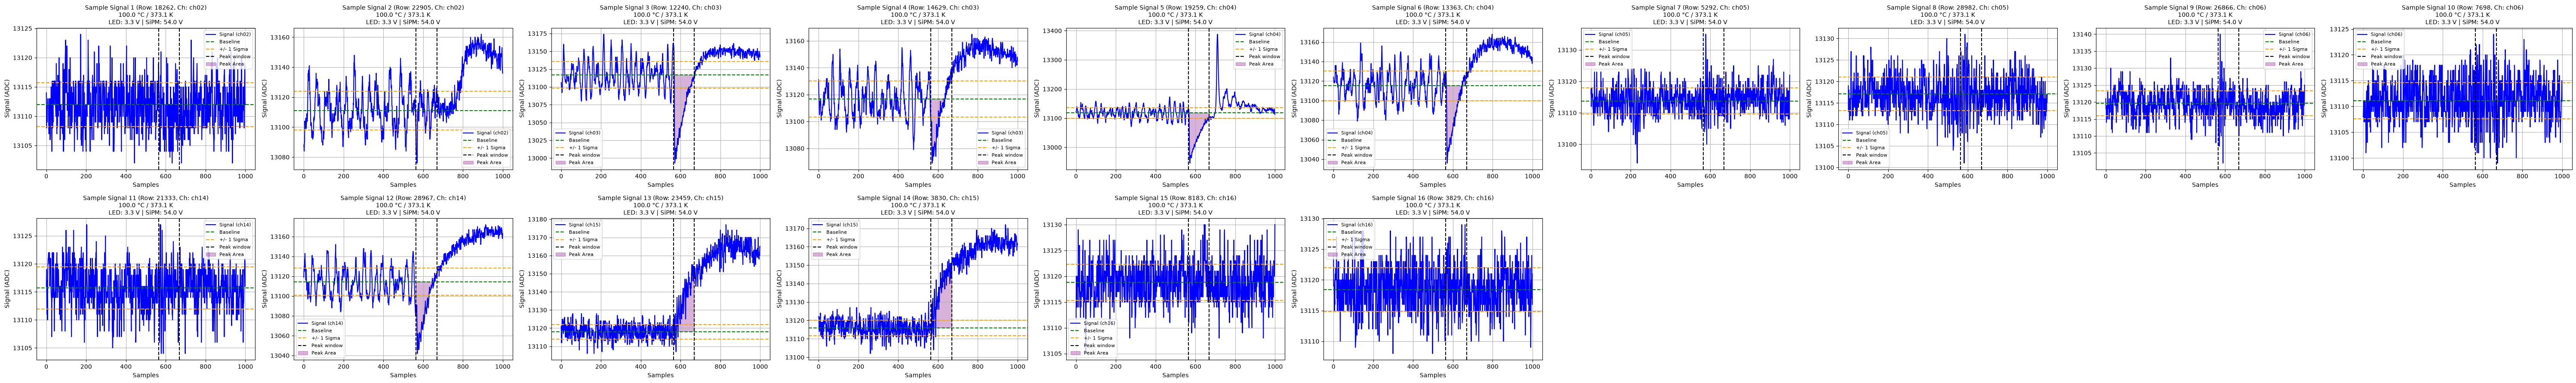

In [30]:
metadata =nbk.parse_folder_metadata(filepath)
#print(metadata)
conditions = [metadata['temp_c'], metadata['led_voltage'], metadata['bias_voltage']]
save_dir = nbk.plot_sample_signals_from_root(filepath, conditions = conditions, num_samples=2, new_path = plot_folder)

In [31]:
#parquet_data  = ("/disk/gfs_atp/xlzd/alpine/analysis/parquets/20260814T130422Z-multi-ch-100c-0-5-2-6-54v-100hz-10ns-3-3v-reuse-a7e79d09.parquet")
fit_df = nbk.fit_all_channels_in_df(parquet_data ,new_path = save_dir, column_to_fit="peak_integral",max_reduced_chi2= 100)


 STARTING ANALYSIS FOR: ch02
Processing 30001 data points for ch02...
Auto-detecting peaks...
Fit rejected: Reduced χ² (1440852374929162124451426647614907664978258444157568822170461475289419210564069799786605851885961986993887686724899242857920886472704.00) > threshold (100).


/home/uzh/hekinc/.venv/lib64/python3.13/site-packages/scipy/optimize/_lsq/common.py:115: RuntimeWarning: overflow encountered in power
  phi_prime = -np.sum(suf ** 2 / denom**3) / p_norm
/home/uzh/hekinc/.venv/lib64/python3.13/site-packages/scipy/optimize/_lsq/common.py:154: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = phi / phi_prime
/home/uzh/hekinc/.venv/lib64/python3.13/site-packages/scipy/optimize/_lsq/common.py:166: RuntimeWarning: divide by zero encountered in scalar divide
  p *= Delta / norm(p)
/home/uzh/hekinc/.venv/lib64/python3.13/site-packages/scipy/optimize/_lsq/common.py:166: RuntimeWarning: invalid value encountered in multiply
  p *= Delta / norm(p)
/home/uzh/hekinc/.venv/lib64/python3.13/site-packages/scipy/optimize/_lsq/common.py:398: RuntimeWarning: invalid value encountered in cast
  return min_step, np.equal(steps, min_step) * np.sign(s).astype(int)
/home/uzh/hekinc/.venv/lib64/python3.13/site-packages/scipy/optimize/_lsq/common.py:283: Ru


 STARTING ANALYSIS FOR: ch03
Processing 30001 data points for ch03...
Auto-detecting peaks...
Physics Curve fitting converged successfully!

--- Physical Fit Results for ch03 ---
  0-Photon Peak: μ = 9.962204e+00, σ = 1.018711e+02
  1-Photon Peak: μ = 5.398649e+02, σ = 7.571564e+02
  2-Photon Peak: μ = 1.069768e+03, σ = 1.065924e+03
  3-Photon Peak: μ = 1.599670e+03, σ = 1.303496e+03
--------------------------------------------------
χ² / NDF:           13778.25 / 443 = 31.102
----------------------------

 STARTING ANALYSIS FOR: ch04
Processing 30001 data points for ch04...
Auto-detecting peaks...
Physics Curve fitting converged successfully!

--- Physical Fit Results for ch04 ---
  0-Photon Peak: μ = 4.917644e+00, σ = 1.075769e+02
  1-Photon Peak: μ = 1.789736e+03, σ = 6.324482e+02
  2-Photon Peak: μ = 3.574554e+03, σ = 8.879238e+02
  3-Photon Peak: μ = 5.359372e+03, σ = 1.084816e+03
--------------------------------------------------
χ² / NDF:           2799.78 / 415 = 6.746
-------

/home/uzh/hekinc/Master/Python/func_notebook.py:117: RuntimeWarning: overflow encountered in exp
  y = A_bg * np.exp(-lambda_bg * x)
/home/uzh/hekinc/.venv/lib64/python3.13/site-packages/scipy/optimize/_lsq/trf.py:353: RuntimeWarning: overflow encountered in dot
  cost_new = 0.5 * np.dot(f_new, f_new)
/home/uzh/hekinc/.venv/lib64/python3.13/site-packages/scipy/optimize/_lsq/common.py:115: RuntimeWarning: invalid value encountered in scalar divide
  phi_prime = -np.sum(suf ** 2 / denom**3) / p_norm



 STARTING ANALYSIS FOR: ch14
Processing 30001 data points for ch14...
Auto-detecting peaks...
Fit rejected: Reduced χ² (741.74) > threshold (100).

 STARTING ANALYSIS FOR: ch15
Processing 30001 data points for ch15...
Auto-detecting peaks...
Fit rejected: Reduced χ² (1645.08) > threshold (100).

 STARTING ANALYSIS FOR: ch16
Processing 30001 data points for ch16...
Auto-detecting peaks...
Optimal parameters not found: Residuals are not finite in the initial point.


/home/uzh/hekinc/Master/Python/func_notebook.py:117: RuntimeWarning: overflow encountered in multiply
  y = A_bg * np.exp(-lambda_bg * x)
/home/uzh/hekinc/.venv/lib64/python3.13/site-packages/scipy/optimize/_numdiff.py:710: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]



All plots successfully saved to /disk/gfs_atp/xlzd/alpine/analysis/plots/20260814T130422Z-multi-ch-100c-0-5-2-6-54v-100hz-10ns-3-3v-reuse-a7e79d09/all_channels_canvas.pdf


Heatmaps saved to: /disk/gfs_atp/xlzd/alpine/analysis/plots/20260814T130422Z-multi-ch-100c-0-5-2-6-54v-100hz-10ns-3-3v-reuse-a7e79d09/heatmaps_all_channels.pdf


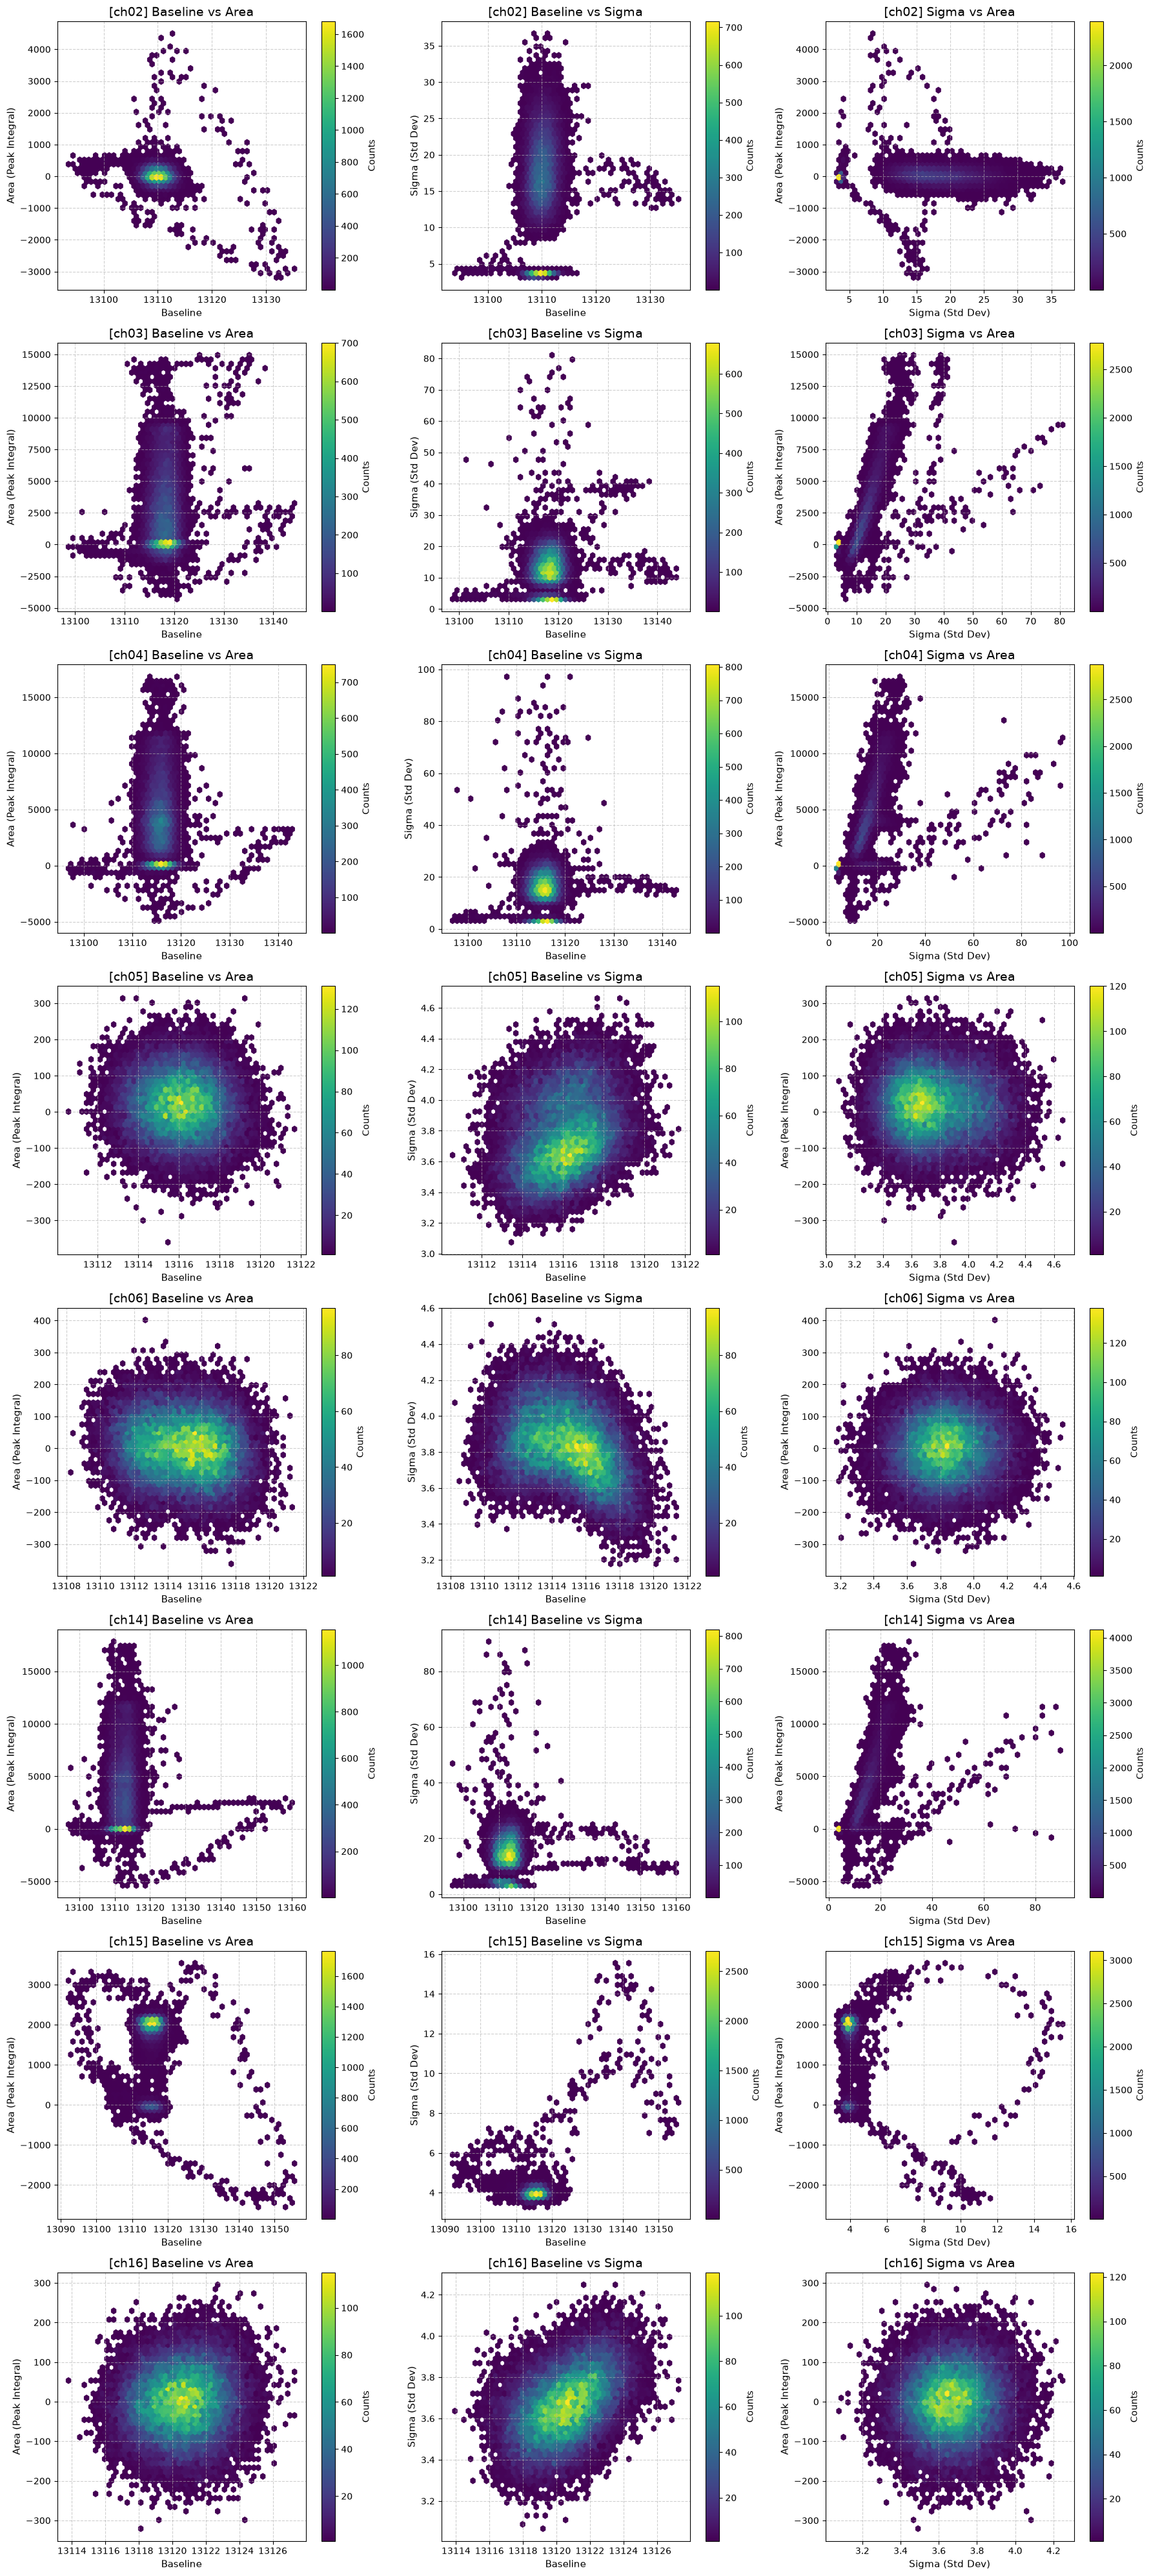

In [ ]:
nbk.plot_waveform_correlations(parquet_data,new_path = save_dir, channel=None, plot_type='hexbin')

Processing ch02...
Processing ch03...
  -> Negative polarity detected on ch03. Auto-inverting.
Processing ch04...
  -> Negative polarity detected on ch04. Auto-inverting.
Processing ch05...
Processing ch06...
Processing ch14...
  -> Negative polarity detected on ch14. Auto-inverting.
Processing ch15...
Processing ch16...
  -> Negative polarity detected on ch16. Auto-inverting.
Data successfully saved  to /disk/gfs_atp/xlzd/alpine/analysis/parquets/20260814T135016Z-multi-ch-100c-0-5-2-6-58v-200hz-10ns-3-3v-d63fa17d.parquet
Sampling ch02...
Sampling ch03...
Sampling ch04...
Sampling ch05...
Sampling ch06...
Sampling ch14...
Sampling ch15...
Sampling ch16...
Combined plot saved to: /disk/gfs_atp/xlzd/alpine/analysis/plots/20260814T135016Z-multi-ch-100c-0-5-2-6-58v-200hz-10ns-3-3v-d63fa17d/combined_sample_signals.pdf


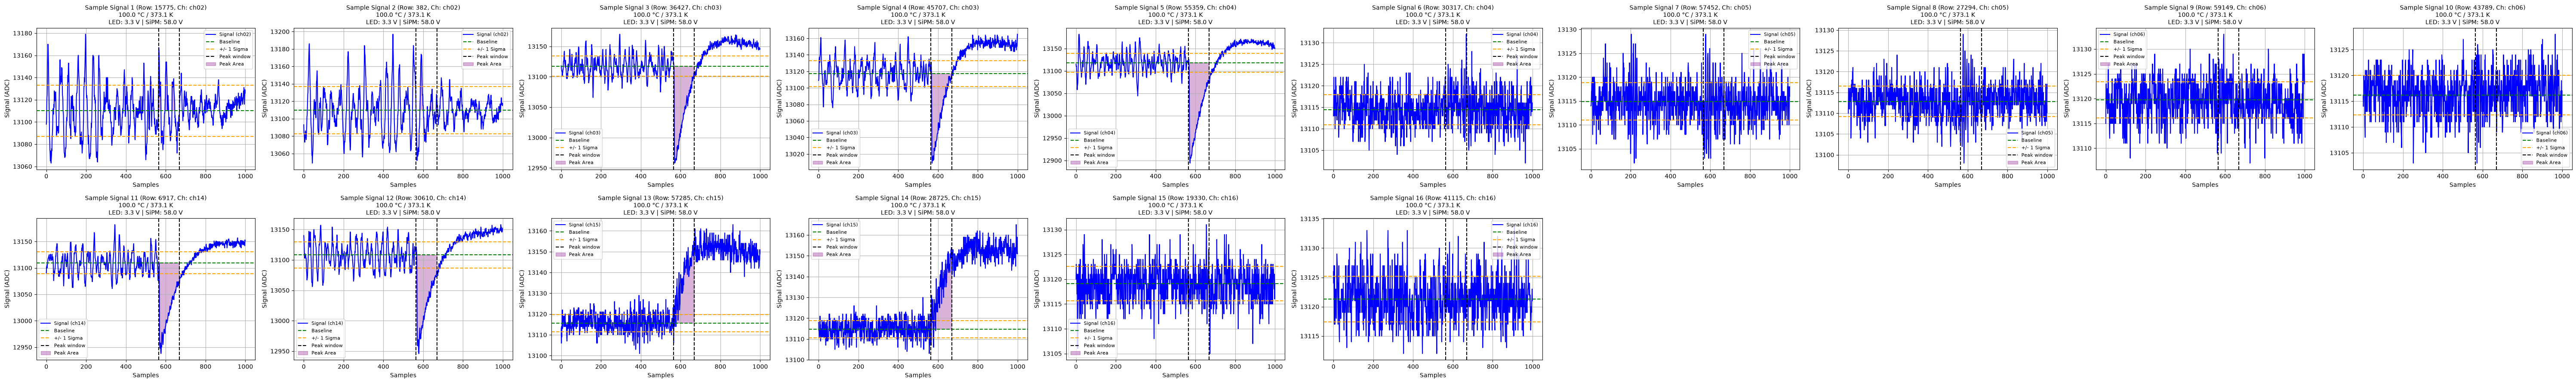


 STARTING ANALYSIS FOR: ch02
Processing 60001 data points for ch02...
Auto-detecting peaks...
Optimal parameters not found: array must not contain infs or NaNs


/home/uzh/hekinc/.venv/lib64/python3.13/site-packages/scipy/optimize/_numdiff.py:711: RuntimeWarning: overflow encountered in divide
  df_dx = [delf / delx for delf, delx in zip(df, dx)]
/home/uzh/hekinc/.venv/lib64/python3.13/site-packages/scipy/optimize/_lsq/least_squares.py:965: RuntimeWarning: overflow encountered in dot
  initial_cost = 0.5 * np.dot(f0, f0)
/home/uzh/hekinc/.venv/lib64/python3.13/site-packages/scipy/optimize/_lsq/trf.py:224: RuntimeWarning: overflow encountered in dot
  cost = 0.5 * np.dot(f, f)
/home/uzh/hekinc/.venv/lib64/python3.13/site-packages/scipy/optimize/_lsq/common.py:595: RuntimeWarning: overflow encountered in dot
  return J.T.dot(f)



 STARTING ANALYSIS FOR: ch03
Processing 60001 data points for ch03...
Auto-detecting peaks...
Fit rejected: Reduced χ² (574.09) > threshold (100).

 STARTING ANALYSIS FOR: ch04
Processing 60001 data points for ch04...
Auto-detecting peaks...
Fit rejected: Reduced χ² (497.50) > threshold (100).

 STARTING ANALYSIS FOR: ch05
Processing 60001 data points for ch05...
Auto-detecting peaks...
Physics Curve fitting converged successfully!

--- Physical Fit Results for ch05 ---
  0-Photon Peak: μ = -1.752341e+02, σ = 1.806363e+01
  1-Photon Peak: μ = -1.302796e+02, σ = 1.994062e+01
  2-Photon Peak: μ = -8.532514e+01, σ = 2.165552e+01
  3-Photon Peak: μ = -4.037066e+01, σ = 2.324425e+01
--------------------------------------------------
χ² / NDF:           543.27 / 386 = 1.407
----------------------------

 STARTING ANALYSIS FOR: ch06
Processing 60001 data points for ch06...
Auto-detecting peaks...
Physics Curve fitting converged successfully!

--- Physical Fit Results for ch06 ---
  0-Photon 

/home/uzh/hekinc/Master/Python/func_notebook.py:117: RuntimeWarning: overflow encountered in exp
  y = A_bg * np.exp(-lambda_bg * x)
/home/uzh/hekinc/Master/Python/func_notebook.py:117: RuntimeWarning: overflow encountered in multiply
  y = A_bg * np.exp(-lambda_bg * x)
/home/uzh/hekinc/.venv/lib64/python3.13/site-packages/scipy/optimize/_numdiff.py:710: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]



All plots successfully saved to /disk/gfs_atp/xlzd/alpine/analysis/plots/20260814T135016Z-multi-ch-100c-0-5-2-6-58v-200hz-10ns-3-3v-d63fa17d/all_channels_canvas.pdf
Heatmaps saved to: /disk/gfs_atp/xlzd/alpine/analysis/plots/20260814T135016Z-multi-ch-100c-0-5-2-6-58v-200hz-10ns-3-3v-d63fa17d/heatmaps_all_channels.pdf


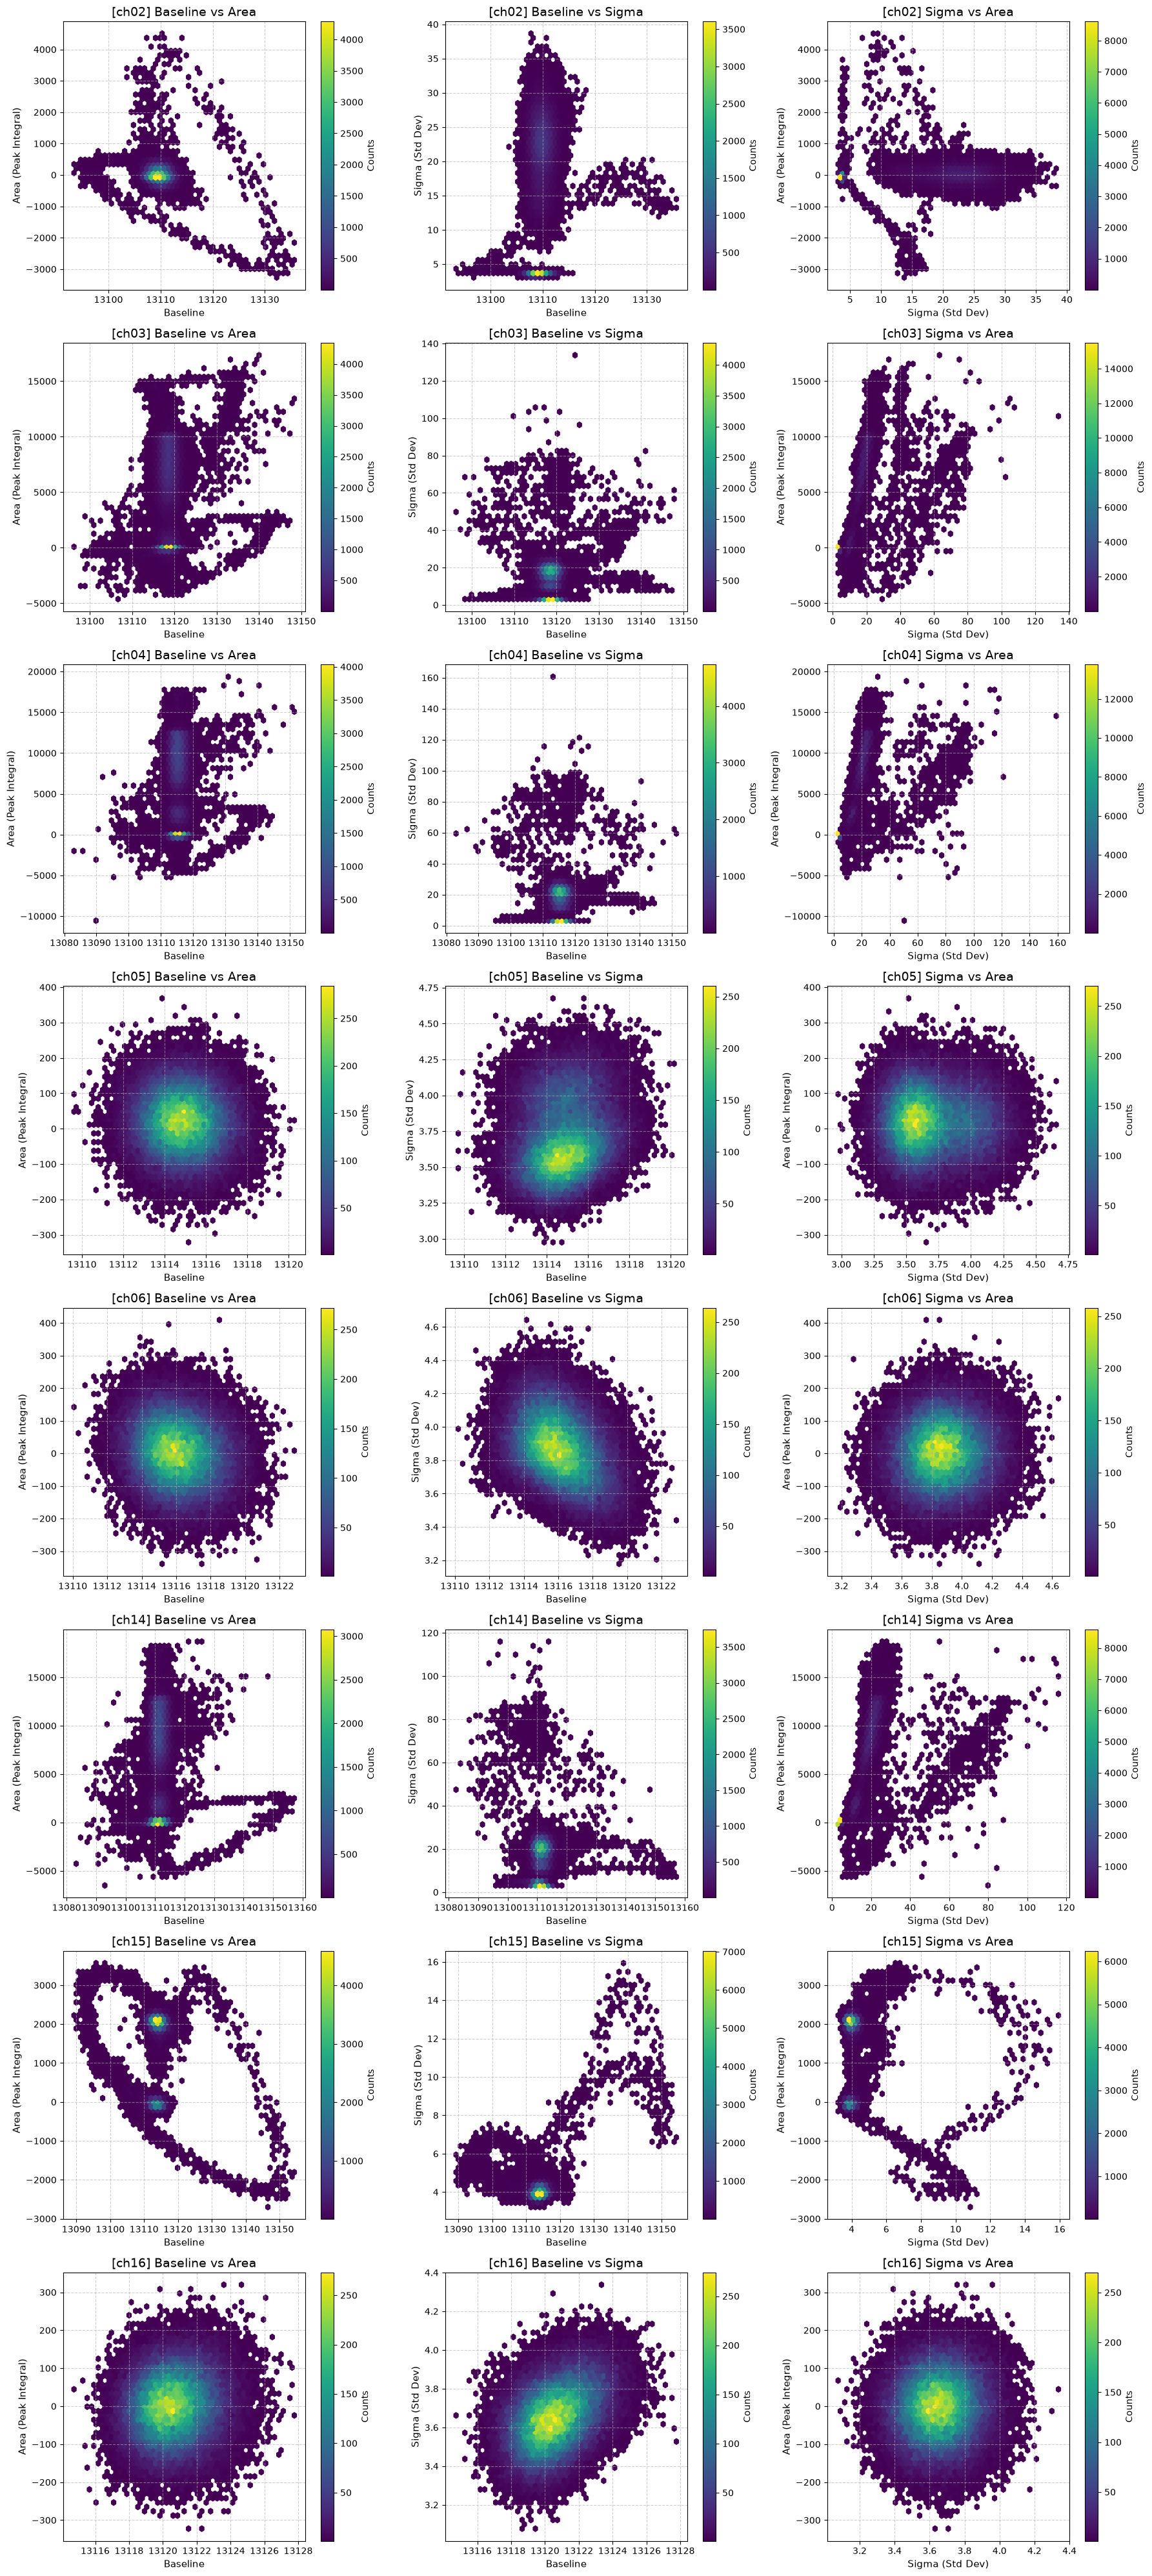

In [34]:
nbk.master_function_root(filepath2)